In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples

def get_base_dir():
    # In a script, __file__ exists; in notebooks it doesn't
    if '__file__' in globals():
        return os.path.dirname(os.path.abspath(__file__))
    else:
        return os.getcwd()

def calculate_marginal_median_and_mad(samples, bins='auto'):
    """
    Per-parameter marginal median and MAD, in a loop style matching
    `calculate_marginal_peak_and_mad`. The `bins` argument is accepted
    for API symmetry but not used.
    """
    # keep the arg to avoid linters complaining it's unused
    _ = bins

    nwalkers, nsteps, ndim = samples.shape
    flat = samples.reshape(-1, ndim)

    medians = np.empty(ndim, dtype=float)
    mads    = np.empty(ndim, dtype=float)

    for i in range(ndim):
        data = flat[:, i]
        medians[i] = np.median(data)
        mads[i]    = np.median(np.abs(data - medians[i]))

    return medians, mads


def calculate_marginal_peak_and_mad(samples, bins='auto'):
    nwalkers, nsteps, ndim = samples.shape
    flat = samples.reshape(-1, ndim)

    peaks = np.empty(ndim)
    mads  = np.empty(ndim)

    for i in range(ndim):
        data = flat[:, i]

        # 1) Histogram-based mode estimate
        hist, edges = np.histogram(data, bins=bins, density=True)
        # find the bin with maximum density
        idx_peak = np.argmax(hist)
        # mode ≈ midpoint of that bin
        peaks[i] = 0.5*(edges[idx_peak] + edges[idx_peak+1])

        # 2) MAD around the mode
        mads[i] = np.median(np.abs(data - peaks[i]))

    return peaks, mads

def plot_triangle_one(samples, param_names, label,
                      output_folder, plot_name, marker=True):
    mcs = MCSamples(samples=samples, names=param_names, label=label)
    g = plots.getSubplotPlotter(width_inch=8)
    g.settings.title_limit_fontsize = 14
    g.settings.axes_fontsize = 14
    g.settings.axes_labelsize = 14

    g.triangle_plot(
        [mcs], param_names,
        filled=True,
        contour_colors=['#4169E1'],
        contour_lws=[1.5],
        alpha=0.6
    )

    if marker:
        medians, mads = calculate_marginal_median_and_mad(samples, bins='auto')
        for i, x0 in enumerate(medians):
            ax = g.subplots[i, i]
            ax.axvline(x0, color='k', ls='--')
            ax.set_title(f"{param_names[i]} = {medians[i]:.3f}±{mads[i]:.3f}",
                         fontsize=12)

    os.makedirs(output_folder, exist_ok=True)
    plt.savefig(os.path.join(output_folder, plot_name),
                bbox_inches='tight', dpi=200)
    plt.show()

Removed no burn in


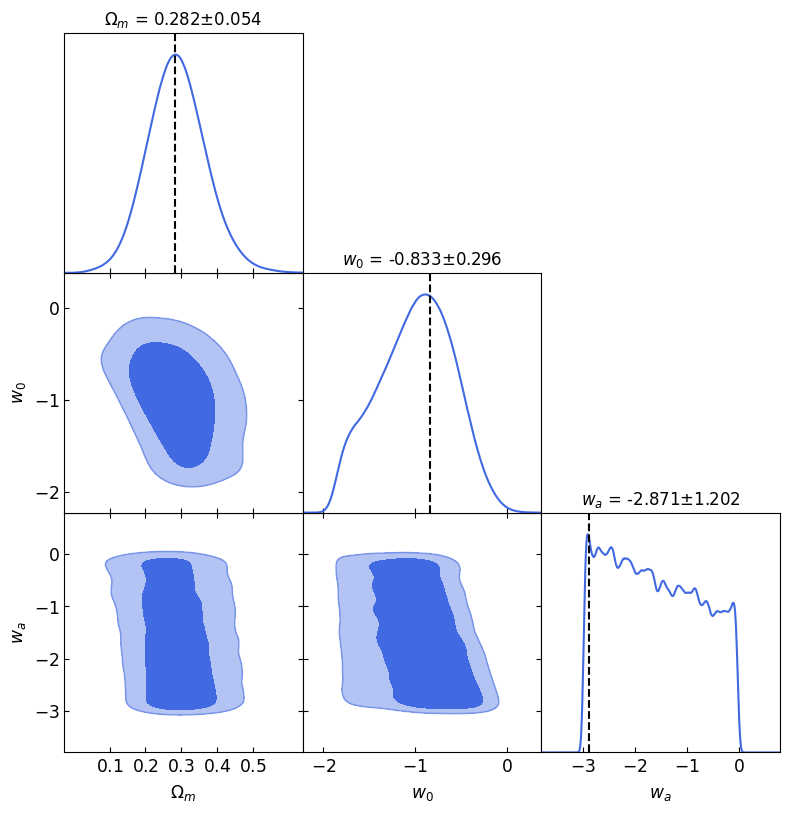

In [26]:

    

# ———————————————— usage ——————————————————
base_dir = r'/home/astrodust/SG/sgl_cosmo/GLS_cosmo01'
evo_label = r"linear"
prior_label = r"Tri"

# 1) Four parameter names in LaTeX
param_names = [r'$\Omega_m$', r'$w_0$', r'$w_a$']

# 2) Load the single chain from relative path
samples_file = os.path.join(base_dir, 'Output', f'{evo_label}-{prior_label}',f"mcmc_cosmop3D-{evo_label}-{prior_label}.npy")
samples = np.load(samples_file)  # shape (nwalkers, nsteps, ndim)

# 3) Call the plot routine with relative output folder
plot_triangle_one(
    samples=samples,
    param_names=param_names,
    label=f'{evo_label}_{prior_label}',
    output_folder=os.path.join(base_dir, 'Results'),
    plot_name=f'triangle_3D_{evo_label}-{prior_label}.png',
    marker=True
)


In [15]:
# # ———————————————— usage ——————————————————
# base_dir = r'/home/astrodust/SG/sgl_cosmo/GLS_cosmo01'
# evo_label = r"linear"
# prior_label = r"Tri-"

# # 1) Four parameter names in LaTeX
# param_names = [r'$\Omega_m$', r'$w_0$', r'$w_a$']

# # 2) Load the single chain from relative path
# samples_file = os.path.join(base_dir, 'Output', f'{evo_label}-{prior_label}',f"mcmc_cosmop3D-{evo_label}-{prior_label}.npy")
# samples = np.load(samples_file)  # shape (nwalkers, nsteps, ndim)

# # 3) Call the plot routine with relative output folder
# plot_triangle_one(
#     samples=samples,
#     param_names=param_names,
#     label=f'{evo_label}_{prior_label}',
#     output_folder=os.path.join(base_dir, 'Results'),
#     plot_name=f'triangle_3D_{evo_label}-{prior_label}.png',
#     marker=True
# )

In [16]:
# # ———————————————— usage ——————————————————
# base_dir = r'/home/astrodust/SG/sgl_cosmo/GLS_cosmo01'
# evo_label = r"linear"
# prior_label = r"Tri-"

# # 1) Four parameter names in LaTeX
# param_names = [r'$\Omega_m$', r'$w_0$']

# # 2) Load the single chain from relative path
# samples_file = os.path.join(base_dir, 'Output', f'{evo_label}-{prior_label}',f"mcmc_cosmop2D-{evo_label}-{prior_label}.npy")
# samples = np.load(samples_file)  # shape (nwalkers, nsteps, ndim)

# # 3) Call the plot routine with relative output folder
# plot_triangle_one(
#     samples=samples,
#     param_names=param_names,
#     label=f'{evo_label}_{prior_label}',
#     output_folder=os.path.join(base_dir, 'Results'),
#     plot_name=f'triangle_2D_{evo_label}-{prior_label}.png',
#     marker=True
# )


Removed no burn in


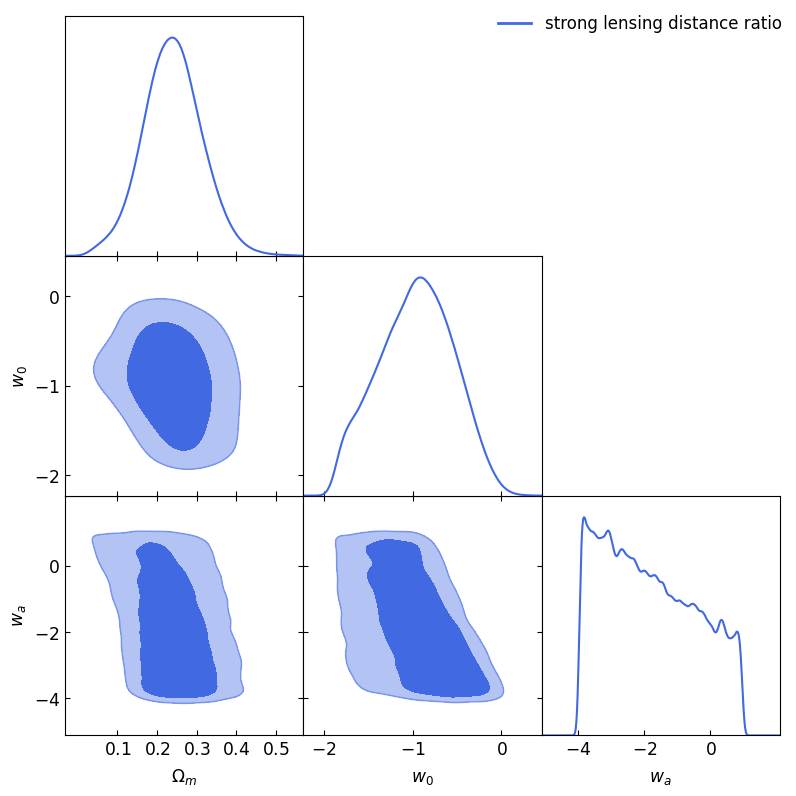

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from getdist import plots, MCSamples

def _weighted_quantile_1d(x, q, w=None):
    x = np.asarray(x, float)
    if w is None:
        return np.quantile(x, q)
    w = np.asarray(w, float)
    s = np.argsort(x)
    xs, ws = x[s], w[s]
    cdf = np.cumsum(ws) / np.sum(ws)
    return np.interp(q, cdf, xs)

def calculate_marginal_median_and_mad_weighted(samples, weights=None, scale=1.4826):
    nwalkers, nsteps, ndim = samples.shape
    flat = samples.reshape(-1, ndim)
    if weights is not None:
        w = np.asarray(weights, float)
        if w.ndim == 2 and w.shape == (nwalkers, nsteps):
            w = w.reshape(-1)
        elif w.ndim == 1 and w.shape == (nwalkers*nsteps,):
            pass
        else:
            raise ValueError("weights 形状需为 (nwalkers, nsteps) 或展平为 (-1,)")
    else:
        w = None

    medians = np.empty(ndim, dtype=float)
    mads    = np.empty(ndim, dtype=float)
    for i in range(ndim):
        xi  = flat[:, i]
        med = _weighted_quantile_1d(xi, 0.5, w)
        mad = _weighted_quantile_1d(np.abs(xi - med), 0.5, w) * scale
        medians[i] = med
        mads[i]    = mad
    return medians, mads

def plot_triangle_one(samples, param_names, label,
                      output_folder, plot_name, marker=True, legend_text="strong lensing distance ratio"):
    mcs = MCSamples(samples=samples, names=param_names, label=label)
    g = plots.getSubplotPlotter(width_inch=8)
    g.settings.title_limit_fontsize = 14
    g.settings.axes_fontsize = 14
    g.settings.axes_labelsize = 14

    contour_color = '#4169E1'
    g.triangle_plot(
        [mcs], param_names,
        filled=True,
        contour_colors=[contour_color],
        contour_lws=[1.5],
        alpha=0.6
    )

    # 可选：在对角线上加中位数标记（使用加权版本，weights=None 等价无权）
    if marker:
        medians, mads = calculate_marginal_median_and_mad_weighted(samples, weights=None, scale=1.4826)
        for i, x0 in enumerate(medians):
            ax = g.subplots[i, i]
            ax.axvline(x0, color='k', ls='--')
            ax.set_title(f"{param_names[i]} = {medians[i]:.3f}±{mads[i]:.3f}", fontsize=12)

    # —— 添加图例（全局 legend）——
    proxy = Line2D([0], [0], color=contour_color, lw=2)
    g.fig.legend(handles=[proxy], labels=[legend_text],
                 loc='upper right', frameon=False, fontsize=12)

    os.makedirs(output_folder, exist_ok=True)
    plt.savefig(os.path.join(output_folder, plot_name), bbox_inches='tight', dpi=200)
    plt.show()


# ———————————————— usage ——————————————————
base_dir = r'/home/astrodust/SG/sgl_cosmo/GLS_cosmo01'
evo_label = r"linear"
prior_label = r"0.22"

# 1) Four parameter names in LaTeX
param_names = [r'$\Omega_m$', r'$w_0$', r'$w_a$']

# 2) Load the single chain from relative path
samples_file = os.path.join(base_dir, 'Output', f'{evo_label}-{prior_label}',f"mcmc_cosmop3D-{evo_label}-{prior_label}.npy")
samples = np.load(samples_file)  # shape (nwalkers, nsteps, ndim)

# 3) Call the plot routine with relative output folder
plot_triangle_one(
    samples=samples,
    param_names=param_names,
    label=f'{evo_label}_{prior_label}',
    output_folder=os.path.join(base_dir, 'Results'),
    plot_name=f'triangle_3D_{evo_label}-{prior_label}.png',
    marker=False
)


Removed no burn in


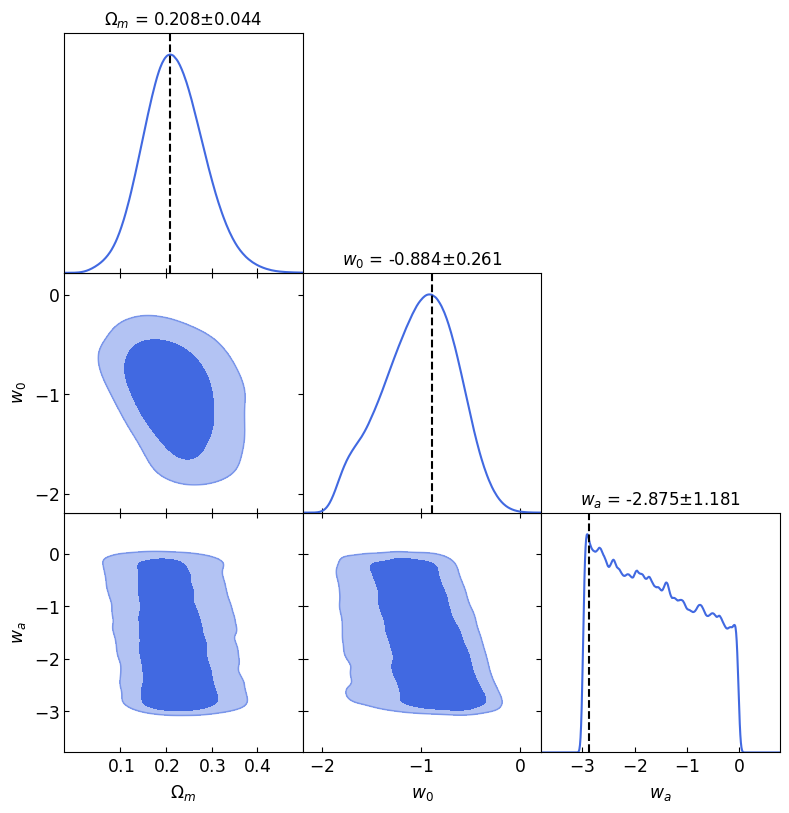

In [20]:

# ———————————————— usage ——————————————————
base_dir = r'/home/astrodust/SG/sgl_cosmo/GLS_cosmo01'
evo_label = r"linear"
prior_label = r"0.18"

# 1) Four parameter names in LaTeX
param_names = [r'$\Omega_m$', r'$w_0$', r'$w_a$']

# 2) Load the single chain from relative path
samples_file = os.path.join(base_dir, 'Output', f'{evo_label}-{prior_label}',f"mcmc_cosmop3D-{evo_label}-{prior_label}.npy")
samples = np.load(samples_file)  # shape (nwalkers, nsteps, ndim)

# 3) Call the plot routine with relative output folder
plot_triangle_one(
    samples=samples,
    param_names=param_names,
    label=f'{evo_label}_{prior_label}',
    output_folder=os.path.join(base_dir, 'Results'),
    plot_name=f'triangle_3D_{evo_label}-{prior_label}.png',
    marker=True
)


In [14]:
def _normalize_pairs(evo_labels, prior_labels):
    """
    Accept either:
      - evo_labels: list[str], prior_labels: list[str] of same length
      - evo_labels: list[tuple[str,str]] and prior_labels: None/[]
    Returns: list of (evo, prior)
    """
    if prior_labels is None or len(prior_labels) == 0:
        # expect evo_labels to be list of tuples
        pairs = list(evo_labels)
    else:
        if len(evo_labels) != len(prior_labels):
            raise ValueError("evo_labels and prior_labels must have the same length.")
        pairs = list(zip(evo_labels, prior_labels))
    return pairs

def _default_colors(n):
    # Use Matplotlib's tab10 cycle repeatedly if needed
    base = plt.rcParams['axes.prop_cycle'].by_key().get('color', [])
    if not base:
        base = [f"C{i}" for i in range(10)]
    colors = [base[i % len(base)] for i in range(n)]
    return colors

def _sanitize_param_labels(param_names):
    """
    GetDist expects LaTeX fragments WITHOUT surrounding $...$.
    This removes any $ so '$\\Omega_k$' -> '\\Omega_k'.
    """
    cleaned = []
    for s in param_names:
        if s is None:
            cleaned.append("")
            continue
        s = str(s).strip().replace("$", "")
        cleaned.append(s)
    return cleaned


# ----------------------- plotting -----------------------

def plot_triangle_multi(
    base_dir,
    param_names,               # e.g. [r'$\Omega_k$', r'$w$']  (dollars allowed; we'll sanitize)
    evo_labels,
    prior_labels=None,
    output_folder=None,
    legend_list=None,
    plot_name="triangle_multi.png",
    bins='auto',
    filled=True,
    add_markers=True,
    colors=None,
    dpi=220,
    axis_labels=None,          # NEW: optional override for axis labels (LaTeX fragments, no $)
):
    pairs = _normalize_pairs(evo_labels, prior_labels)
    ndim = len(param_names)

    # Internal parameter codes that GetDist will use to reference params
    param_codes = [f"p{i}" for i in range(ndim)]

    # --- labels to show on axes ---
    # If user provides axis_labels, use them; otherwise sanitize param_names
    if axis_labels is not None:
        if len(axis_labels) != ndim:
            raise ValueError("axis_labels must have same length as param_names.")
        labels_show = _sanitize_param_labels(axis_labels)
    else:
        labels_show = _sanitize_param_labels(param_names)

    mcs_list = []
    legend_labels = []
    peak_mad_list = []

    for evo, prior in pairs:
        folder = os.path.join(base_dir, "Output", f"{evo}-{prior}")
        fname  = os.path.join(folder, f"mcmc_cosmop{ndim}D-{evo}-{prior}.npy")
        if not os.path.isfile(fname):
            raise FileNotFoundError(f"Missing samples file: {fname}")

        arr = np.load(fname)  # (nwalkers, nsteps, ndim)
        if arr.ndim != 3 or arr.shape[-1] != ndim:
            raise ValueError(
                f"Samples in {fname} have shape {arr.shape}, expected (*, *, {ndim})."
            )

        flat = arr.reshape(-1, ndim)
        label = f"{evo}_{prior}"

        # IMPORTANT: names=param_codes, labels=labels_show (NO $)
        mcs = MCSamples(samples=flat, names=param_codes, labels=labels_show, label=label)
        mcs_list.append(mcs)
        # legend_labels.append(label)
        legend_labels = legend_list

        peak_mad_list.append(calculate_marginal_peak_and_mad(arr, bins=bins))

    if colors is None:
        colors = _default_colors(len(mcs_list))

    g = plots.getSubplotPlotter(width_inch=8)
    # Slightly larger labels/ticks for readability
    g.settings.axes_labelsize = 20
    g.settings.axes_fontsize  = 20
    g.settings.legend_fontsize = 16
    g.settings.title_limit_fontsize = 14
    # Ensure LaTeX is used for labels; GetDist handles it when labels lack $...$

    # Use param_codes here (NOT the LaTeX with $)
    g.triangle_plot(
        mcs_list,
        param_codes,
        filled=filled,
        alpha = 0.5,
        contour_colors=colors,
        contour_ls=['-'] * len(mcs_list),
        contour_lws=[1.5] * len(mcs_list),
        legend_labels=legend_labels,
        legend_loc='upper right'
    )

    # if add_markers:
    #     for i in range(ndim):
    #         ax = g.subplots[i, i]
    #         for j, (peaks, mads) in enumerate(peak_mad_list):
    #             ax.axvline(peaks[i], ls='--', lw=1.0, color=colors[j], alpha=0.9)
    #         # Use sanitized label in the title, wrap with $ here only
    #         lbl = labels_show[i]
    #         peaks0, mads0 = peak_mad_list[0]
    #         ax.set_title(f"${lbl}$ = {peaks0[i]:.3f}±{mads0[i]:.3f}", fontsize=12)

    if output_folder is None:
        output_folder = os.path.join(base_dir, "Results")
    os.makedirs(output_folder, exist_ok=True)
    outpath = os.path.join(output_folder, plot_name)
    plt.savefig(outpath, bbox_inches='tight', dpi=dpi)
    plt.show()
    # print(f"Saved: {outpath}")



Removed no burn in
Removed no burn in


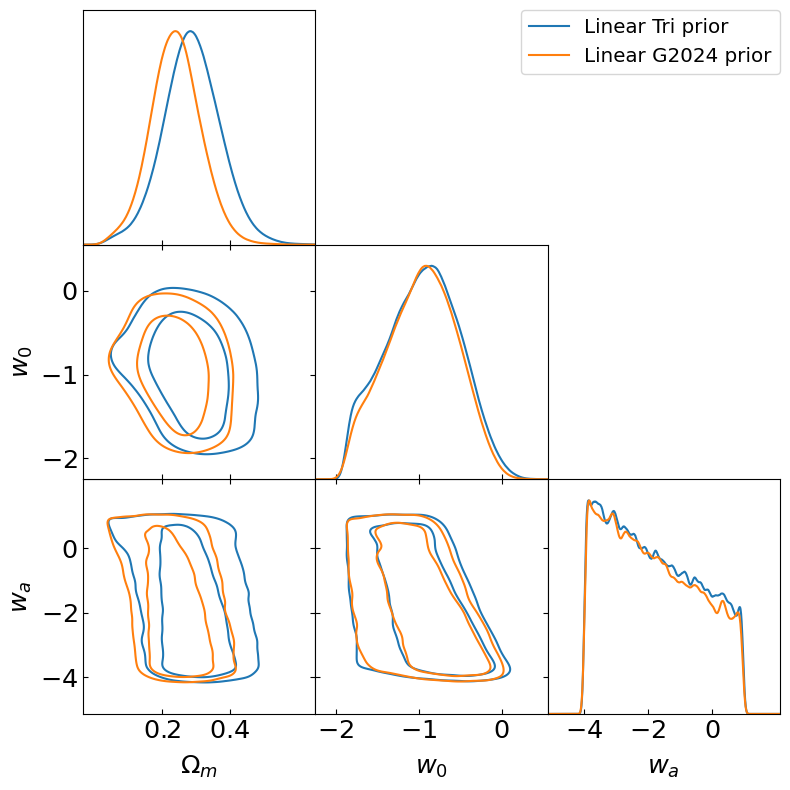

In [16]:
if __name__ == "__main__":
    base_dir = r'/home/astrodust/SG/sgl_cosmo/GLS_cosmo01'
    param_names = [r'$\Omega_m$', r'$w_0$', r'$w_a$']

    # Option A: two parallel lists
    evo_list   = ["linear", "linear"]
    prior_list = ["Tri", "0.22"]

    plot_triangle_multi(
        base_dir=base_dir,
        param_names=param_names,
        evo_labels=evo_list,
        prior_labels=prior_list,
        output_folder=os.path.join(base_dir, "Results"),
        legend_list=[r'Linear Tri prior', r'Linear G2024 prior'],
        plot_name="triangle_3D_multi_linear_w0waCDM.png",
        filled=False,
        add_markers=True
    )

Removed no burn in


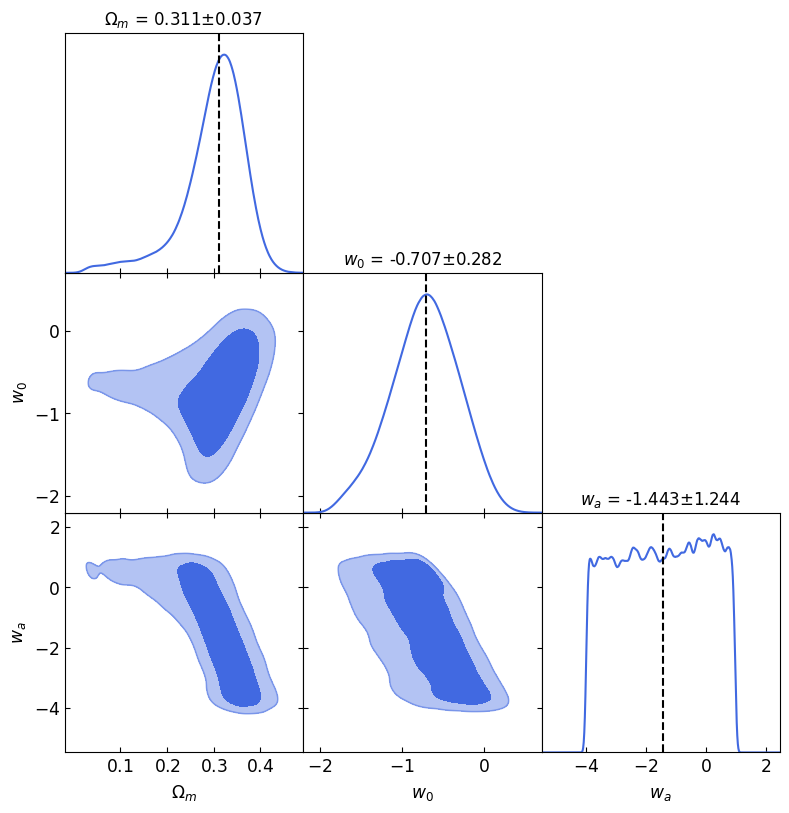

In [5]:

# ———————————————— usage ——————————————————
base_dir = r'/home/astrodust/SG/sgl_cosmo/GLS_cosmo01'
evo_label = r"linear"
prior_label = r"DESa_sim_l3-0.22"

# 1) Four parameter names in LaTeX
param_names = [r'$\Omega_m$', r'$w_0$', r'$w_a$']

# 2) Load the single chain from relative path
samples_file = os.path.join(base_dir, 'Output', f'{evo_label}-{prior_label}',f"mcmc_cosmop3D-{evo_label}-{prior_label}.npy")
samples = np.load(samples_file)  # shape (nwalkers, nsteps, ndim)

# 3) Call the plot routine with relative output folder
plot_triangle_one(
    samples=samples,
    param_names=param_names,
    label=f'{evo_label}_{prior_label}',
    output_folder=os.path.join(base_dir, 'Results'),
    plot_name=f'triangle_3D_{evo_label}-{prior_label}.png',
    marker=True
)


In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from getdist import plots, MCSamples

def calculate_marginal_median_and_mad_weighted(samples, weights=None, scale=1.4826):
    """
    samples:
      encourages either
        - 2D: (nsamp, ndim)
        - 3D: (nwalkers, nsteps, ndim)
    weights (optional):
        - None
        - 1D: (nsamp,)
        - 2D: (nwalkers, nsteps)
    """
    arr = np.asarray(samples)
    if arr.ndim == 3:
        nwalkers, nsteps, ndim = arr.shape
        flat = arr.reshape(-1, ndim)
        if weights is not None:
            w = np.asarray(weights, float)
            if w.shape == (nwalkers, nsteps):
                w = w.reshape(-1)
            elif w.shape == (nwalkers * nsteps,):
                pass
            else:
                raise ValueError("3D samples: weights must be (nwalkers,nsteps) or flattened (nwalkers*nsteps,)")
        else:
            w = None

    elif arr.ndim == 2:
        nsamp, ndim = arr.shape
        flat = arr
        if weights is not None:
            w = np.asarray(weights, float)
            if w.shape == (nsamp,):
                pass
            else:
                raise ValueError("2D samples: weights must be (nsamp,) or None")
        else:
            w = None

    else:
        raise ValueError(f"samples must be 2D or 3D, got shape {arr.shape}")

    medians = np.empty(ndim, dtype=float)
    mads    = np.empty(ndim, dtype=float)
    for i in range(ndim):
        xi  = flat[:, i]
        med = _weighted_quantile_1d(xi, 0.5, w)
        mad = _weighted_quantile_1d(np.abs(xi - med), 0.5, w) * scale
        medians[i] = med
        mads[i]    = mad
    return medians, mads

def _strip_outer_dollars(s: str) -> str:
    s = str(s).strip()
    if len(s) >= 2 and s[0] == '$' and s[-1] == '$':
        return s[1:-1]
    return s

def _as_2d_samples(samples):
    """
    Accepts samples with shape:
      - (nsamp, ndim)
      - (nwalkers, nsteps, ndim)
    Returns: flat_2d (nsamp_flat, ndim), ndim
    """
    arr = np.asarray(samples)
    if arr.ndim == 2:
        flat = arr
    elif arr.ndim == 3:
        nwalkers, nsteps, ndim = arr.shape
        flat = arr.reshape(nwalkers * nsteps, ndim)
    else:
        raise ValueError(f"samples must be 2D or 3D, got shape {arr.shape}")
    if flat.shape[1] < 1:
        raise ValueError(f"ndim must be >= 1, got {flat.shape[1]}")
    return flat, flat.shape[1]

def plot_triangle_one(samples, param_names=None, label="",
                      output_folder=".", plot_name="triangle.png",
                      marker=True, legend_text="strong lensing distance ratio"):
    """
    Auto-detects input samples dimensionality:
      - if samples is (nwalkers, nsteps, ndim): flattens to (nwalkers*nsteps, ndim)
      - if samples is (nsamp, ndim): uses as-is

    param_names:
      - None  -> auto-generate names p0..p{ndim-1}
      - list length < ndim -> uses first len(list) dimensions
      - list length == ndim -> uses all
    """
    flat, ndim_all = _as_2d_samples(samples)

    # Determine which dims to plot
    if param_names is None:
        names = [f"p{i}" for i in range(ndim_all)]
        labels = [f"p{i}" for i in range(ndim_all)]
        flat_use = flat
    else:
        if not isinstance(param_names, (list, tuple)):
            raise ValueError("param_names must be a list/tuple or None")
        k = len(param_names)
        if k == 0:
            raise ValueError("param_names cannot be empty")
        if k > ndim_all:
            raise ValueError(f"param_names length ({k}) > ndim in samples ({ndim_all})")
        # Use first k dimensions if fewer names are provided
        flat_use = flat[:, :k]
        names = [f"p{i}" for i in range(k)]          # internal names for getdist
        labels = list(param_names)                    # display labels (can be LaTeX)

    # Create getdist samples
    mcs = MCSamples(samples=flat_use, names=param_names, label=label)

    g = plots.getSubplotPlotter(width_inch=8)
    g.settings.title_limit_fontsize = 14
    g.settings.axes_fontsize = 14
    g.settings.axes_labelsize = 14

    contour_color = '#4169E1'
    g.triangle_plot(
        [mcs], param_names,
        filled=True,
        contour_colors=[contour_color],
        contour_lws=[1.5],
        alpha=0.6
    )

    # Optional: median + MAD markers on diagonal
    if marker:
        medians, mads = calculate_marginal_median_and_mad_weighted(flat_use, weights=None, scale=1.4826)
        for i, x0 in enumerate(medians):
            ax = g.subplots[i, i]
            ax.axvline(x0, color='k', ls='--')
            ax.set_title(rf"{param_names[i]} = {medians[i]:.3f}±{mads[i]:.3f}", fontsize=12)


    # Global legend
    proxy = Line2D([0], [0], color=contour_color, lw=2)
    g.fig.legend(handles=[proxy], labels=[legend_text],
                 loc='upper right', frameon=False, fontsize=12)

    os.makedirs(output_folder, exist_ok=True)
    plt.savefig(os.path.join(output_folder, plot_name), bbox_inches='tight', dpi=200)
    plt.show()


# base_dir = r'/home/astrodust/SG/sgl_cosmo/GLS_cosmo01'
# evo_label = r"fullhier-ann"
# prior_label = r"gaussian-hier"

# # 1) Four parameter names in LaTeX
# param_names = [r'$\Omega_m$', r'$w$']

# # 2) Load the single chain from relative path
# samples_file = os.path.join(base_dir, 'Output', f'{evo_label}-{prior_label}',f"mcmc_cosmop493D-{evo_label}-{prior_label}.npy")
# samples = np.load(samples_file)  # shape (nwalkers, nsteps, ndim)

# samples3 = np.load(samples_file)                 # (nwalkers, nsteps, 493)
# nwalkers, nsteps, ndim = samples3.shape

# burn = int(0.1 * nsteps)                         # 自己调
# flat = samples3[:, burn:, :].reshape(-1, ndim)   # (Nsamples, 493)

# cosmo = flat[:, :2]     

# plot_triangle_one(
#     samples=cosmo,
#     param_names=[r'$\Omega_m$', r'$w$'],   # 只给两个名字 -> 自动取前两维
#     label=f'{evo_label}_{prior_label}',
#     output_folder=os.path.join(base_dir, 'Results'),
#     plot_name=f'triangle_2D_{evo_label}-{prior_label}_Om_w.png',
#     marker=True
# )

Removed no burn in


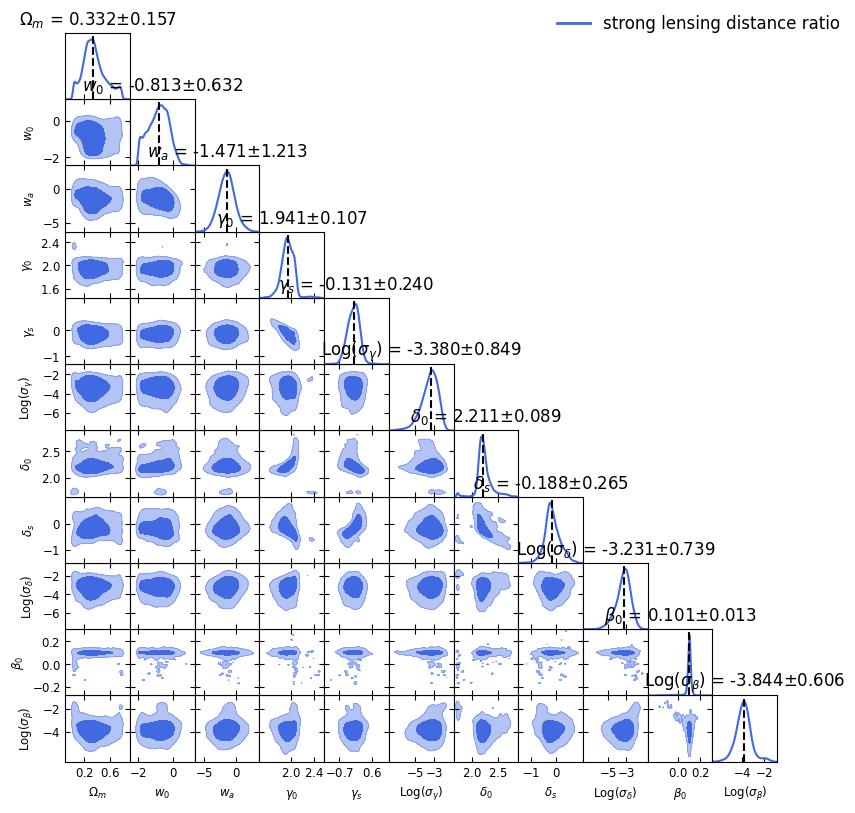

In [24]:
base_dir = r'/home/astrodust/SG/sgl_cosmo/GLS_cosmo01'
evo_label = r"fullhier-ann"
prior_label = r"gaussian-hier-evow-tri"

# 1) Four parameter names in LaTeX
param_names = [r'$\Omega_m$', r'$w_0$', r'$w_a$']

# 2) Load the single chain from relative path
samples_file = os.path.join(base_dir, 'Output', f'{evo_label}-{prior_label}',f"mcmc_cosmop494D-{evo_label}-{prior_label}.npy")
samples = np.load(samples_file)  # shape (nwalkers, nsteps, ndim)

samples3 = np.load(samples_file)                 # (nwalkers, nsteps, 493)
nwalkers, nsteps, ndim = samples3.shape

burn = int(0.1 * nsteps)                         # 自己调
flat = samples3[:, burn:, :].reshape(-1, ndim)   # (Nsamples, 493)

cosmo = flat[:, :11]     

plot_triangle_one(
    samples=cosmo,
    param_names=[r'$\Omega_m$', r'$w_0$', r'$w_a$',
                 r'$\gamma_0$',r'$\gamma_s$',r'$\mathrm{Log}(\sigma_{\gamma})$',
                 r'$\delta_0$',r'$\delta_s$',r'$\mathrm{Log}(\sigma_{\delta})$',
                 r'$\beta_0$',r'$\mathrm{Log}(\sigma_{\beta}$)'],   # 只给两个名字 -> 自动取前两维
    label=f'{evo_label}_{prior_label}',
    output_folder=os.path.join(base_dir, 'Results'),
    plot_name=f'triangle_11D_{evo_label}-{prior_label}_w0waCDM.png',
    marker=True
)

Removed no burn in


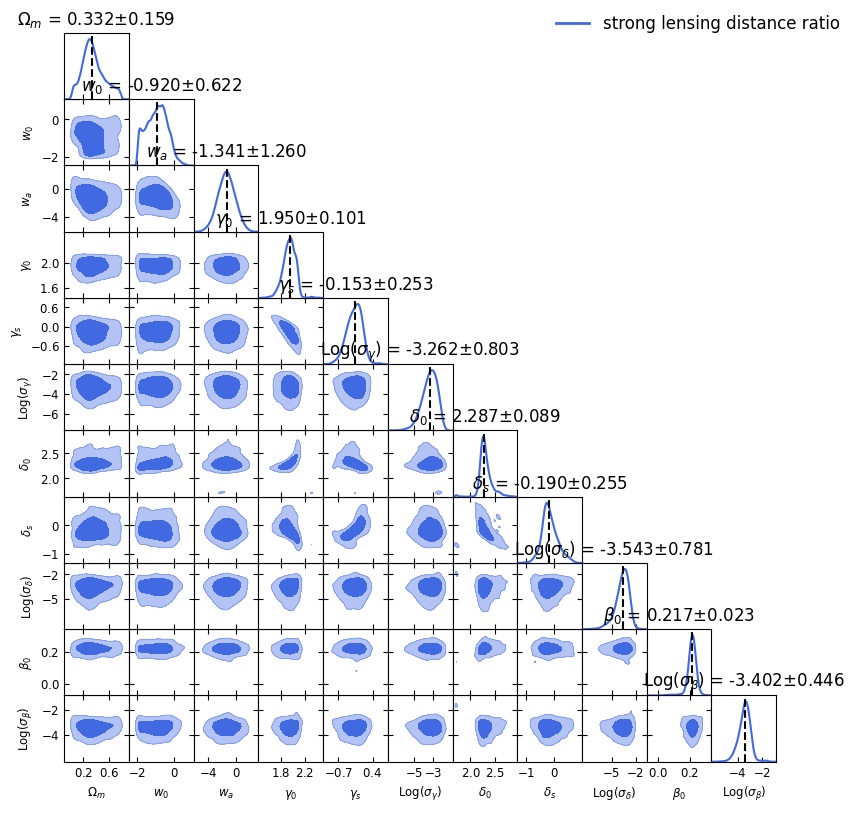

In [25]:
base_dir = r'/home/astrodust/SG/sgl_cosmo/GLS_cosmo01'
evo_label = r"fullhier-ann"
prior_label = r"gaussian-hier-evow-gauss"

# 1) Four parameter names in LaTeX
param_names = [r'$\Omega_m$', r'$w_0$', r'$w_a$']

# 2) Load the single chain from relative path
samples_file = os.path.join(base_dir, 'Output', f'{evo_label}-{prior_label}',f"mcmc_cosmop494D-{evo_label}-{prior_label}.npy")
samples = np.load(samples_file)  # shape (nwalkers, nsteps, ndim)

samples3 = np.load(samples_file)                 # (nwalkers, nsteps, 493)
nwalkers, nsteps, ndim = samples3.shape

burn = int(0.1 * nsteps)                         # 自己调
flat = samples3[:, burn:, :].reshape(-1, ndim)   # (Nsamples, 493)

cosmo = flat[:, :11]     

plot_triangle_one(
    samples=cosmo,
    param_names=[r'$\Omega_m$', r'$w_0$', r'$w_a$',
                 r'$\gamma_0$',r'$\gamma_s$',r'$\mathrm{Log}(\sigma_{\gamma})$',
                 r'$\delta_0$',r'$\delta_s$',r'$\mathrm{Log}(\sigma_{\delta})$',
                 r'$\beta_0$',r'$\mathrm{Log}(\sigma_{\beta}$)'],   # 只给两个名字 -> 自动取前两维
    label=f'{evo_label}_{prior_label}',
    output_folder=os.path.join(base_dir, 'Results'),
    plot_name=f'triangle_11D_{evo_label}-{prior_label}_w0waCDM_gauss.png',
    marker=True
)

Removed no burn in


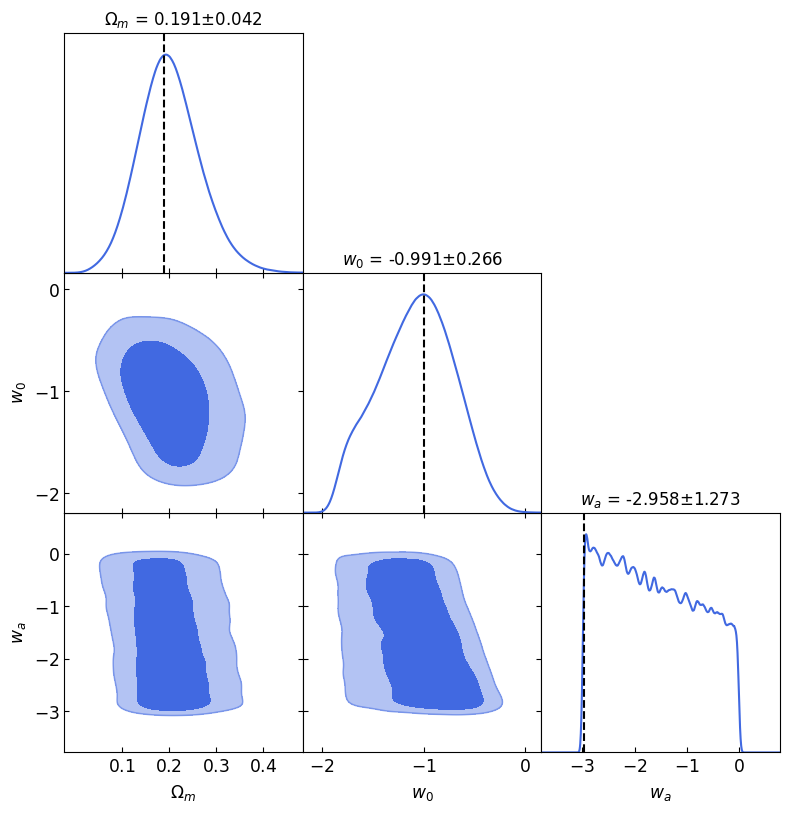

In [21]:

# ———————————————— usage ——————————————————
base_dir = r'/home/astrodust/SG/sgl_cosmo/GLS_cosmo01'
evo_label = r"CPL"
prior_label = r"Tri"

# 1) Four parameter names in LaTeX
param_names = [r'$\Omega_m$', r'$w_0$', r'$w_a$']

# 2) Load the single chain from relative path
samples_file = os.path.join(base_dir, 'Output', f'{evo_label}-{prior_label}',f"mcmc_cosmop3D-{evo_label}-{prior_label}.npy")
samples = np.load(samples_file)  # shape (nwalkers, nsteps, ndim)

# 3) Call the plot routine with relative output folder
plot_triangle_one(
    samples=samples,
    param_names=param_names,
    label=f'{evo_label}_{prior_label}',
    output_folder=os.path.join(base_dir, 'Results'),
    plot_name=f'triangle_3D_{evo_label}-{prior_label}.png',
    marker=True
)


Removed no burn in


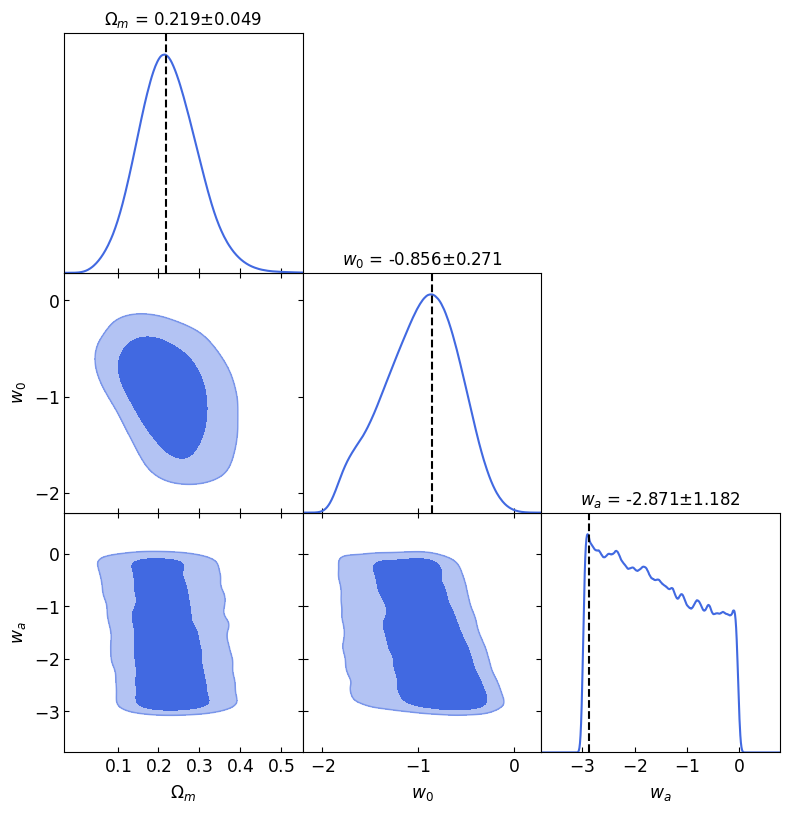

In [22]:

# ———————————————— usage ——————————————————
base_dir = r'/home/astrodust/SG/sgl_cosmo/GLS_cosmo01'
evo_label = r"CPL"
prior_label = r"0.22"

# 1) Four parameter names in LaTeX
param_names = [r'$\Omega_m$', r'$w_0$', r'$w_a$']

# 2) Load the single chain from relative path
samples_file = os.path.join(base_dir, 'Output', f'{evo_label}-{prior_label}',f"mcmc_cosmop3D-{evo_label}-{prior_label}.npy")
samples = np.load(samples_file)  # shape (nwalkers, nsteps, ndim)

# 3) Call the plot routine with relative output folder
plot_triangle_one(
    samples=samples,
    param_names=param_names,
    label=f'{evo_label}_{prior_label}',
    output_folder=os.path.join(base_dir, 'Results'),
    plot_name=f'triangle_3D_{evo_label}-{prior_label}.png',
    marker=True
)


Removed no burn in


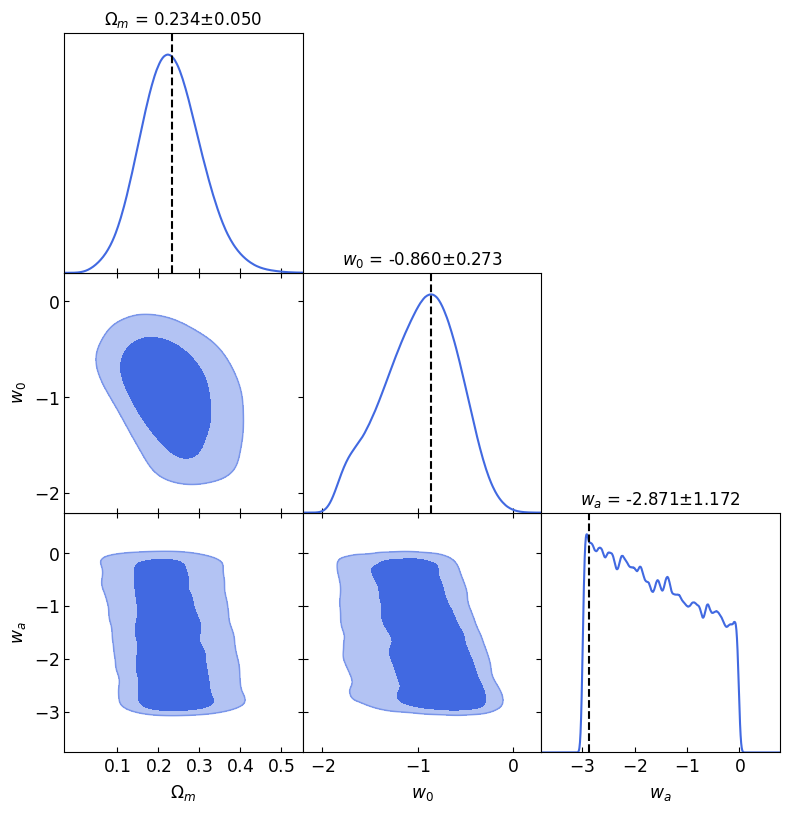

In [23]:

# ———————————————— usage ——————————————————
base_dir = r'/home/astrodust/SG/sgl_cosmo/GLS_cosmo01'
evo_label = r"CPL"
prior_label = r"0.18"

# 1) Four parameter names in LaTeX
param_names = [r'$\Omega_m$', r'$w_0$', r'$w_a$']

# 2) Load the single chain from relative path
samples_file = os.path.join(base_dir, 'Output', f'{evo_label}-{prior_label}',f"mcmc_cosmop3D-{evo_label}-{prior_label}.npy")
samples = np.load(samples_file)  # shape (nwalkers, nsteps, ndim)

# 3) Call the plot routine with relative output folder
plot_triangle_one(
    samples=samples,
    param_names=param_names,
    label=f'{evo_label}_{prior_label}',
    output_folder=os.path.join(base_dir, 'Results'),
    plot_name=f'triangle_3D_{evo_label}-{prior_label}.png',
    marker=True
)


Removed no burn in


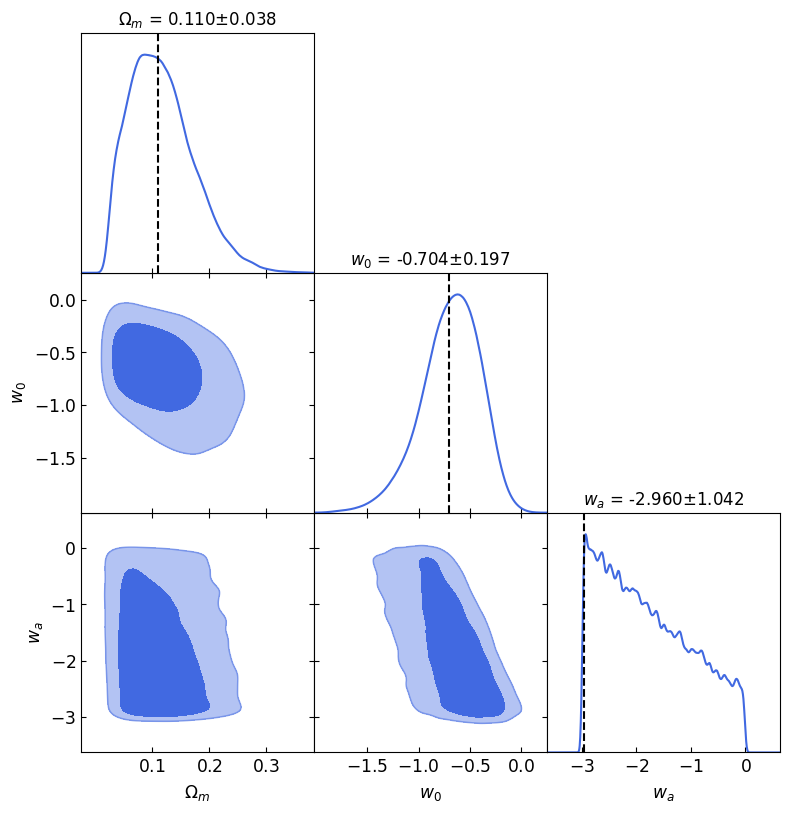

In [24]:

# ———————————————— usage ——————————————————
base_dir = r'/home/astrodust/SG/sgl_cosmo/GLS_cosmo01'
evo_label = r"linear-Etherington"
prior_label = r"LD"

# 1) Four parameter names in LaTeX
param_names = [r'$\Omega_m$', r'$w_0$', r'$w_a$']

# 2) Load the single chain from relative path
samples_file = os.path.join(base_dir, 'Output', f'{evo_label}-{prior_label}',f"mcmc_cosmop3D-{evo_label}-{prior_label}.npy")
samples = np.load(samples_file)  # shape (nwalkers, nsteps, ndim)

# 3) Call the plot routine with relative output folder
plot_triangle_one(
    samples=samples,
    param_names=param_names,
    label=f'{evo_label}_{prior_label}',
    output_folder=os.path.join(base_dir, 'Results'),
    plot_name=f'triangle_3D_{evo_label}-{prior_label}.png',
    marker=True
)


Removed no burn in


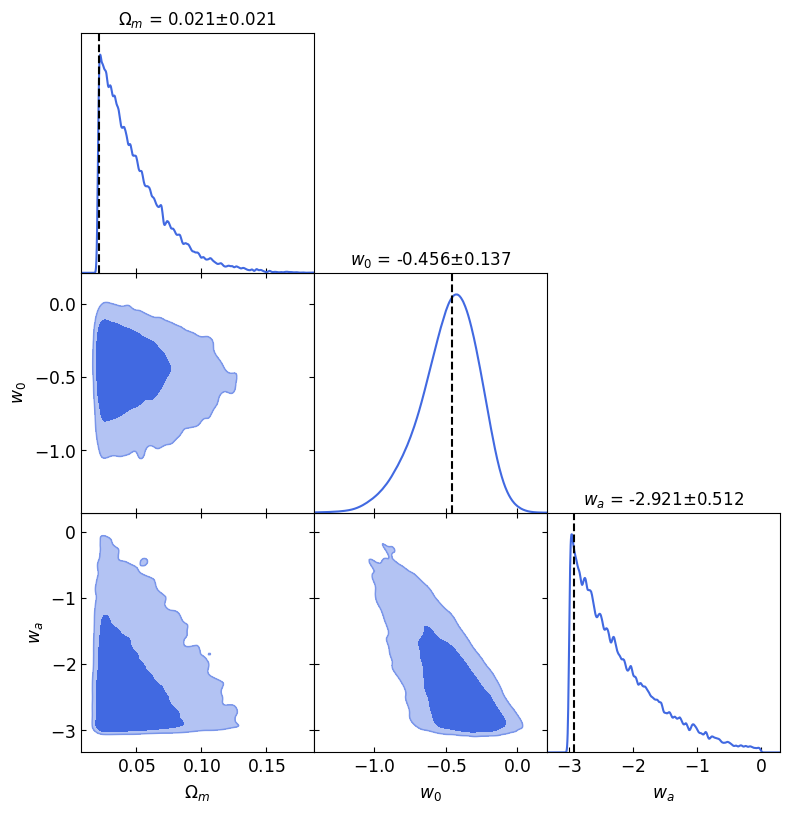

In [25]:

# ———————————————— usage ——————————————————
base_dir = r'/home/astrodust/SG/sgl_cosmo/GLS_cosmo01'
evo_label = r"linear-Etherington"
prior_label = r"OL"

# 1) Four parameter names in LaTeX
param_names = [r'$\Omega_m$', r'$w_0$', r'$w_a$']

# 2) Load the single chain from relative path
samples_file = os.path.join(base_dir, 'Output', f'{evo_label}-{prior_label}',f"mcmc_cosmop3D-{evo_label}-{prior_label}.npy")
samples = np.load(samples_file)  # shape (nwalkers, nsteps, ndim)

# 3) Call the plot routine with relative output folder
plot_triangle_one(
    samples=samples,
    param_names=param_names,
    label=f'{evo_label}_{prior_label}',
    output_folder=os.path.join(base_dir, 'Results'),
    plot_name=f'triangle_3D_{evo_label}-{prior_label}.png',
    marker=True
)
